In [31]:
# Import Libraries for Feature Engineering and Modeling

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

# For handling imbalanced data
from imblearn.over_sampling import SMOTE

# For model tracking
import mlflow
import mlflow.sklearn

# XGBoost
import xgboost as xgb

print("All libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"Scikit-learn imported successfully")
print(f"XGBoost version: {xgb.__version__}")

All libraries imported successfully!
Pandas version: 2.2.3
Scikit-learn imported successfully
XGBoost version: 3.0.0


In [32]:
# Load Dataset

# Load the data
df = pd.read_csv('../data/raw/telecom_churn.csv')

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

# Display first few rows
df.head()

Dataset loaded successfully!
Shape: (7043, 21)
Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [33]:
# Handle Missing Values

print("HANDLING MISSING VALUES")
print("="*60)

# Check missing values
print("\nMissing values before handling:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Fix TotalCharges data type and missing values
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print(f"\nTotalCharges missing values: {df['TotalCharges'].isnull().sum()}")

# Strategy: Fill missing TotalCharges with 0 (these are new customers)
df['TotalCharges'].fillna(0, inplace=True)

print(f"\nAfter filling with 0: {df['TotalCharges'].isnull().sum()} missing values")

# Verify no missing values remain
print("\nMissing values after handling:")
missing_after = df.isnull().sum().sum()
if missing_after == 0:
    print("No missing values remaining!")
else:
    print(f"Still have {missing_after} missing values")
    print(df.isnull().sum()[df.isnull().sum() > 0])

HANDLING MISSING VALUES

Missing values before handling:
Series([], dtype: int64)

TotalCharges missing values: 11

After filling with 0: 0 missing values

Missing values after handling:
No missing values remaining!


In [34]:
# Remove Unnecessary Features

print("REMOVING UNNECESSARY FEATURES")
print("="*60)

# Remove customerID (not useful for prediction)
print("\nRemoving: customerID (just an identifier)")
df_model = df.drop('customerID', axis=1)

# Remove TotalCharges (highly correlated with tenure)
print("Removing: TotalCharges (correlated with tenure × MonthlyCharges)")
df_model = df_model.drop('TotalCharges', axis=1)

print(f"\nFeatures remaining: {df_model.shape[1]}")
print(f"Columns: {df_model.columns.tolist()}")

REMOVING UNNECESSARY FEATURES

Removing: customerID (just an identifier)
Removing: TotalCharges (correlated with tenure × MonthlyCharges)

Features remaining: 19
Columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'Churn']


In [35]:
# Separate Features and Target

print("SEPARATING FEATURES AND TARGET")
print("="*60)

# Separate target variable
X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

print(f"\nFeatures (X): {X.shape}")
print(f"Target (y): {y.shape}")

print(f"\nTarget distribution:")
print(y.value_counts())
print(f"\nTarget percentages:")
print(y.value_counts(normalize=True) * 100)

SEPARATING FEATURES AND TARGET

Features (X): (7043, 18)
Target (y): (7043,)

Target distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Target percentages:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [36]:
# Encode Target Variable

print("ENCODING TARGET VARIABLE")
print("="*60)

# Convert Churn to binary (0 and 1)
y = y.map({'No': 0, 'Yes': 1})

print(f"\nTarget encoding:")
print("No  → 0")
print("Yes → 1")

print(f"\nEncoded target distribution:")
print(y.value_counts())
print(f"\nClass 0 (No Churn): {(y == 0).sum()}")
print(f"Class 1 (Churn): {(y == 1).sum()}")

ENCODING TARGET VARIABLE

Target encoding:
No  → 0
Yes → 1

Encoded target distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64

Class 0 (No Churn): 5174
Class 1 (Churn): 1869


In [37]:
# Identify Categorical and Numerical Features

print("IDENTIFYING FEATURE TYPES")
print("="*60)

# Identify categorical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

# Identify numerical columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"\nCategorical features ({len(categorical_cols)}):")
for col in categorical_cols:
    print(f"   - {col}")

print(f"\nNumerical features ({len(numerical_cols)}):")
for col in numerical_cols:
    print(f"   - {col}")

IDENTIFYING FEATURE TYPES

Categorical features (15):
   - gender
   - Partner
   - Dependents
   - PhoneService
   - MultipleLines
   - InternetService
   - OnlineSecurity
   - OnlineBackup
   - DeviceProtection
   - TechSupport
   - StreamingTV
   - StreamingMovies
   - Contract
   - PaperlessBilling
   - PaymentMethod

Numerical features (3):
   - SeniorCitizen
   - tenure
   - MonthlyCharges


In [38]:
# Encode Categorical Variables

print("ENCODING CATEGORICAL VARIABLES")
print("="*60)

# Make a copy
X_encoded = X.copy()

# Binary categorical columns (Yes/No)
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']

print("\nEncoding binary columns (Yes/No → 1/0):")
for col in binary_cols:
    if col in X_encoded.columns:
        X_encoded[col] = X_encoded[col].map({'Yes': 1, 'No': 0})
        print(f"    {col}")

# Gender (Male/Female → 1/0)
print("\n Encoding gender:")
X_encoded['gender'] = X_encoded['gender'].map({'Male': 1, 'Female': 0})
print(f"   gender (Male→1, Female→0)")

# Multi-category columns - use One-Hot Encoding
multi_category_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 
                       'OnlineBackup', 'DeviceProtection', 'TechSupport',
                       'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']

print("\n One-Hot Encoding multi-category columns:")
X_encoded = pd.get_dummies(X_encoded, columns=multi_category_cols, drop_first=True)

print(f"\n Encoding complete!")
print(f"Features before encoding: {X.shape[1]}")
print(f"Features after encoding: {X_encoded.shape[1]}")
print(f"\nNew feature count: {X_encoded.shape[1]} (added {X_encoded.shape[1] - X.shape[1]} dummy variables)")

ENCODING CATEGORICAL VARIABLES

Encoding binary columns (Yes/No → 1/0):
    Partner
    Dependents
    PhoneService
    PaperlessBilling

 Encoding gender:
   gender (Male→1, Female→0)

 One-Hot Encoding multi-category columns:

 Encoding complete!
Features before encoding: 18
Features after encoding: 29

New feature count: 29 (added 11 dummy variables)


In [39]:
# Feature Scaling

print("FEATURE SCALING")
print("="*60)

# Identify columns that need scaling (numerical columns)
cols_to_scale = ['tenure', 'MonthlyCharges']

print(f"\nColumns to scale: {cols_to_scale}")

# Create scaler
scaler = StandardScaler()

# Scale the features
X_encoded[cols_to_scale] = scaler.fit_transform(X_encoded[cols_to_scale])

print("\nScaling complete!")
print("\nExample - Before and After scaling:")
print("tenure and MonthlyCharges are now normalized (mean=0, std=1)")

FEATURE SCALING

Columns to scale: ['tenure', 'MonthlyCharges']

Scaling complete!

Example - Before and After scaling:
tenure and MonthlyCharges are now normalized (mean=0, std=1)


In [40]:
# Train-Test Split

print("SPLITTING DATA INTO TRAIN AND TEST SETS")
print("="*60)

# Split the data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # Maintain class distribution
)

print(f"\n Dataset split:")
print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X_encoded)*100:.1f}%)")
print(f"Test set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X_encoded)*100:.1f}%)")

print(f"\n Target distribution in training set:")
print(f"Class 0 (No Churn): {(y_train == 0).sum()} ({(y_train == 0).sum()/len(y_train)*100:.1f}%)")
print(f"Class 1 (Churn): {(y_train == 1).sum()} ({(y_train == 1).sum()/len(y_train)*100:.1f}%)")

print(f"\n Target distribution in test set:")
print(f"Class 0 (No Churn): {(y_test == 0).sum()} ({(y_test == 0).sum()/len(y_test)*100:.1f}%)")
print(f"Class 1 (Churn): {(y_test == 1).sum()} ({(y_test == 1).sum()/len(y_test)*100:.1f}%)")

print("\nData ready for modeling!")

SPLITTING DATA INTO TRAIN AND TEST SETS

 Dataset split:
Training set: 5634 samples (80.0%)
Test set: 1409 samples (20.0%)

 Target distribution in training set:
Class 0 (No Churn): 4139 (73.5%)
Class 1 (Churn): 1495 (26.5%)

 Target distribution in test set:
Class 0 (No Churn): 1035 (73.5%)
Class 1 (Churn): 374 (26.5%)

Data ready for modeling!


In [41]:
# Train Baseline Model - Logistic Regression

print("TRAINING BASELINE MODEL: LOGISTIC REGRESSION")
print("="*60)

# Initialize the model
log_reg = LogisticRegression(random_state=42, max_iter=1000)

# Train the model
print("\n Training Logistic Regression...")
log_reg.fit(X_train, y_train)
print(" Training complete!")

# Make predictions
print("\n Making predictions on test set...")
y_pred_log = log_reg.predict(X_test)
y_pred_proba_log = log_reg.predict_proba(X_test)[:, 1]  # Probability of churn

# Evaluate the model
print("\n MODEL PERFORMANCE:")
print("="*60)

accuracy = accuracy_score(y_test, y_pred_log)
precision = precision_score(y_test, y_pred_log)
recall = recall_score(y_test, y_pred_log)
f1 = f1_score(y_test, y_pred_log)
roc_auc = roc_auc_score(y_test, y_pred_proba_log)

print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall:    {recall:.4f} ({recall*100:.2f}%)")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

print("\n" + "="*60)
print(" Baseline model trained successfully!")

TRAINING BASELINE MODEL: LOGISTIC REGRESSION

 Training Logistic Regression...
 Training complete!

 Making predictions on test set...

 MODEL PERFORMANCE:
Accuracy:  0.7970 (79.70%)
Precision: 0.6375 (63.75%)
Recall:    0.5455 (54.55%)
F1-Score:  0.5879
ROC-AUC:   0.8392

 Baseline model trained successfully!


 CONFUSION MATRIX


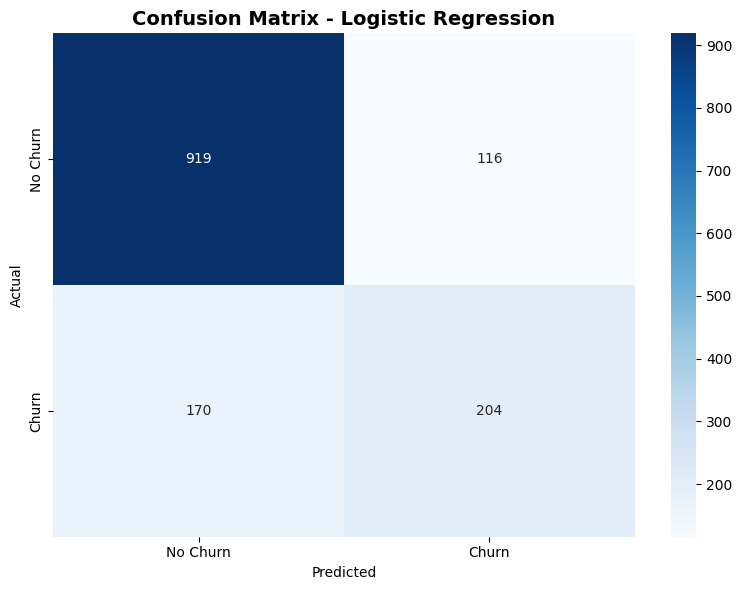


 Confusion Matrix Breakdown:
True Negatives (Correctly predicted No Churn):  919
False Positives (Incorrectly predicted Churn):  116
False Negatives (Missed Churners):              170
True Positives (Correctly predicted Churn):     204

 Detailed Classification Report:
              precision    recall  f1-score   support

    No Churn       0.84      0.89      0.87      1035
       Churn       0.64      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409



In [42]:
# Confusion Matrix for Logistic Regression

print(" CONFUSION MATRIX")
print("="*60)

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred_log)

# Visualize
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix - Logistic Regression', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# Detailed breakdown
print("\n Confusion Matrix Breakdown:")
print(f"True Negatives (Correctly predicted No Churn):  {cm[0][0]}")
print(f"False Positives (Incorrectly predicted Churn):  {cm[0][1]}")
print(f"False Negatives (Missed Churners):              {cm[1][0]}")
print(f"True Positives (Correctly predicted Churn):     {cm[1][1]}")

# Classification report
print("\n Detailed Classification Report:")
print(classification_report(y_test, y_pred_log, 
                          target_names=['No Churn', 'Churn']))

In [43]:
# Train Random Forest Model

print("TRAINING RANDOM FOREST MODEL")
print("="*60)

# Initialize Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,      # Number of trees
    random_state=42,
    max_depth=10,
    min_samples_split=50,
    n_jobs=-1              # Use all CPU cores
)

# Train the model
print("\n Training Random Forest (100 trees)...")
rf_model.fit(X_train, y_train)
print(" Training complete!")

# Make predictions
print("\n Making predictions on test set...")
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluate the model
print("\n MODEL PERFORMANCE:")
print("="*60)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)

print(f"Accuracy:  {accuracy_rf:.4f} ({accuracy_rf*100:.2f}%)")
print(f"Precision: {precision_rf:.4f} ({precision_rf*100:.2f}%)")
print(f"Recall:    {recall_rf:.4f} ({recall_rf*100:.2f}%)")
print(f"F1-Score:  {f1_rf:.4f}")
print(f"ROC-AUC:   {roc_auc_rf:.4f}")

print("\n" + "="*60)
print(" Random Forest model trained successfully!")

TRAINING RANDOM FOREST MODEL

 Training Random Forest (100 trees)...
 Training complete!

 Making predictions on test set...

 MODEL PERFORMANCE:
Accuracy:  0.7999 (79.99%)
Precision: 0.6783 (67.83%)
Recall:    0.4679 (46.79%)
F1-Score:  0.5538
ROC-AUC:   0.8427

 Random Forest model trained successfully!


MODEL COMPARISON

               Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Logistic Regression  0.797019   0.637500 0.545455  0.587896 0.839242
      Random Forest  0.799858   0.678295 0.467914  0.553797 0.842658


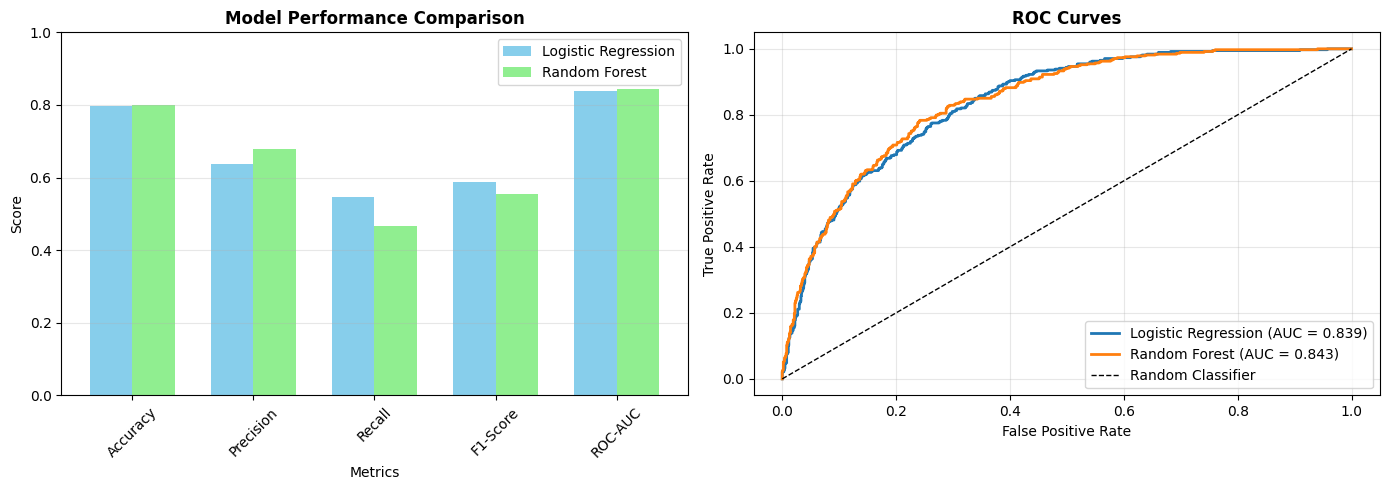


 Which model is better?
 Logistic Regression performs better (F1: 0.5879 vs 0.5538)


In [44]:
# Compare Model Performance

print("MODEL COMPARISON")
print("="*60)

# Create comparison dataframe
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [accuracy, accuracy_rf],
    'Precision': [precision, precision_rf],
    'Recall': [recall, recall_rf],
    'F1-Score': [f1, f1_rf],
    'ROC-AUC': [roc_auc, roc_auc_rf]
})

print("\n", comparison.to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Metrics comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
log_reg_scores = [accuracy, precision, recall, f1, roc_auc]
rf_scores = [accuracy_rf, precision_rf, recall_rf, f1_rf, roc_auc_rf]

x = np.arange(len(metrics))
width = 0.35

axes[0].bar(x - width/2, log_reg_scores, width, label='Logistic Regression', color='skyblue')
axes[0].bar(x + width/2, rf_scores, width, label='Random Forest', color='lightgreen')
axes[0].set_xlabel('Metrics')
axes[0].set_ylabel('Score')
axes[0].set_title('Model Performance Comparison', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics, rotation=45)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_ylim([0, 1])

# Plot 2: ROC Curves
from sklearn.metrics import roc_curve

fpr_log, tpr_log, _ = roc_curve(y_test, y_pred_proba_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)

axes[1].plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {roc_auc:.3f})', linewidth=2)
axes[1].plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.3f})', linewidth=2)
axes[1].plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n Which model is better?")
if f1_rf > f1:
    print(f" Random Forest performs better (F1: {f1_rf:.4f} vs {f1:.4f})")
else:
    print(f" Logistic Regression performs better (F1: {f1:.4f} vs {f1_rf:.4f})")

In [45]:
# Train XGBoost Model

print("TRAINING XGBOOST MODEL")
print("="*60)

# Initialize XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

# Train the model
print("\nTraining XGBoost...")
xgb_model.fit(X_train, y_train)
print("Training complete!")

# Make predictions
print("\nMaking predictions on test set...")
y_pred_xgb = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Evaluate the model
print("\nMODEL PERFORMANCE:")
print("="*60)

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)

print(f"Accuracy:  {accuracy_xgb:.4f} ({accuracy_xgb*100:.2f}%)")
print(f"Precision: {precision_xgb:.4f} ({precision_xgb*100:.2f}%)")
print(f"Recall:    {recall_xgb:.4f} ({recall_xgb*100:.2f}%)")
print(f"F1-Score:  {f1_xgb:.4f}")
print(f"ROC-AUC:   {roc_auc_xgb:.4f}")

print("\n" + "="*60)
print("XGBoost model trained successfully!")

TRAINING XGBOOST MODEL

Training XGBoost...
Training complete!

Making predictions on test set...

MODEL PERFORMANCE:
Accuracy:  0.7892 (78.92%)
Precision: 0.6238 (62.38%)
Recall:    0.5187 (51.87%)
F1-Score:  0.5664
ROC-AUC:   0.8362

XGBoost model trained successfully!


In [46]:
# Handle Class Imbalance with SMOTE

print("HANDLING CLASS IMBALANCE WITH SMOTE")
print("="*60)

print("\nBefore SMOTE:")
print(f"Class 0 (No Churn): {(y_train == 0).sum()}")
print(f"Class 1 (Churn):    {(y_train == 1).sum()}")
print(f"Ratio: {(y_train == 0).sum() / (y_train == 1).sum():.2f}:1")

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(f"Class 0 (No Churn): {(y_train_smote == 0).sum()}")
print(f"Class 1 (Churn):    {(y_train_smote == 1).sum()}")
print(f"Ratio: {(y_train_smote == 0).sum() / (y_train_smote == 1).sum():.2f}:1")

print("\nDataset is now balanced!")

# Train Random Forest with SMOTE
print("\nTraining Random Forest with SMOTE...")
rf_smote = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=10,
    min_samples_split=50,
    n_jobs=-1
)

rf_smote.fit(X_train_smote, y_train_smote)

# Predictions
y_pred_rf_smote = rf_smote.predict(X_test)
y_pred_proba_rf_smote = rf_smote.predict_proba(X_test)[:, 1]

# Evaluate
accuracy_rf_smote = accuracy_score(y_test, y_pred_rf_smote)
precision_rf_smote = precision_score(y_test, y_pred_rf_smote)
recall_rf_smote = recall_score(y_test, y_pred_rf_smote)
f1_rf_smote = f1_score(y_test, y_pred_rf_smote)
roc_auc_rf_smote = roc_auc_score(y_test, y_pred_proba_rf_smote)

print("\nRandom Forest + SMOTE Performance:")
print("="*60)
print(f"Accuracy:  {accuracy_rf_smote:.4f} ({accuracy_rf_smote*100:.2f}%)")
print(f"Precision: {precision_rf_smote:.4f} ({precision_rf_smote*100:.2f}%)")
print(f"Recall:    {recall_rf_smote:.4f} ({recall_rf_smote*100:.2f}%)")
print(f"F1-Score:  {f1_rf_smote:.4f}")
print(f"ROC-AUC:   {roc_auc_rf_smote:.4f}")

print("\nComparison with original Random Forest:")
print(f"Recall improved: {recall_rf:.4f} → {recall_rf_smote:.4f} ({(recall_rf_smote - recall_rf)*100:+.2f}%)")

HANDLING CLASS IMBALANCE WITH SMOTE

Before SMOTE:
Class 0 (No Churn): 4139
Class 1 (Churn):    1495
Ratio: 2.77:1

After SMOTE:
Class 0 (No Churn): 4139
Class 1 (Churn):    4139
Ratio: 1.00:1

Dataset is now balanced!

Training Random Forest with SMOTE...

Random Forest + SMOTE Performance:
Accuracy:  0.7502 (75.02%)
Precision: 0.5204 (52.04%)
Recall:    0.7513 (75.13%)
F1-Score:  0.6149
ROC-AUC:   0.8393

Comparison with original Random Forest:
Recall improved: 0.4679 → 0.7513 (+28.34%)


FEATURE IMPORTANCE ANALYSIS

Top 15 Most Important Features:
                             Feature  Importance
                              tenure    0.258883
         InternetService_Fiber optic    0.114243
                   Contract_Two year    0.093498
                      MonthlyCharges    0.087035
      PaymentMethod_Electronic check    0.074234
                   Contract_One year    0.048410
                  OnlineSecurity_Yes    0.044641
                     TechSupport_Yes    0.037376
 StreamingMovies_No internet service    0.023869
                    OnlineBackup_Yes    0.022995
                    PaperlessBilling    0.019475
    OnlineBackup_No internet service    0.016786
  OnlineSecurity_No internet service    0.014510
     TechSupport_No internet service    0.014021
DeviceProtection_No internet service    0.013800


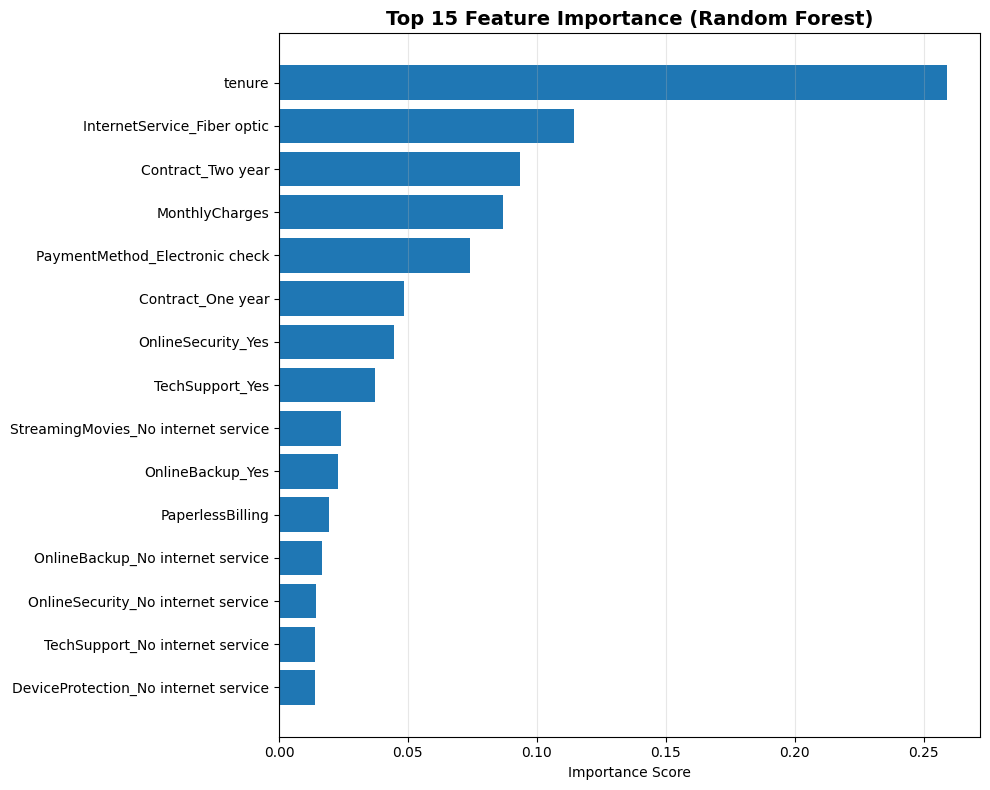


Features with very low importance (< 0.01): 10

Low importance features:
                        Feature  Importance
           DeviceProtection_Yes    0.009932
             InternetService_No    0.009918
                  SeniorCitizen    0.009581
StreamingTV_No internet service    0.009226
                StreamingTV_Yes    0.008189
                         gender    0.008124
            StreamingMovies_Yes    0.007785
     PaymentMethod_Mailed check    0.004529
 MultipleLines_No phone service    0.002872
                   PhoneService    0.002800

Consider removing these features and retraining


In [47]:
# Feature Importance Analysis

print("FEATURE IMPORTANCE ANALYSIS")
print("="*60)

# Get feature importance from Random Forest
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 15 Most Important Features:")
print(feature_importance.head(15).to_string(index=False))

# Visualize
plt.figure(figsize=(10, 8))
top_features = feature_importance.head(15)
plt.barh(range(len(top_features)), top_features['Importance'])
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Importance Score')
plt.title('Top 15 Feature Importance (Random Forest)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# Check if any features are very unimportant
low_importance = feature_importance[feature_importance['Importance'] < 0.01]
print(f"\nFeatures with very low importance (< 0.01): {len(low_importance)}")
if len(low_importance) > 0:
    print("\nLow importance features:")
    print(low_importance.to_string(index=False))
    print("\nConsider removing these features and retraining")

FINAL MODEL COMPARISON

                 Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
  Logistic Regression  0.797019   0.637500 0.545455  0.587896 0.839242
        Random Forest  0.799858   0.678295 0.467914  0.553797 0.842658
              XGBoost  0.789212   0.623794 0.518717  0.566423 0.836156
Random Forest + SMOTE  0.750177   0.520370 0.751337  0.614880 0.839305

Best Model for Each Metric:
Best Accuracy:  Random Forest (0.7999)
Best Precision: Random Forest (0.6783)
Best Recall:    Random Forest + SMOTE (0.7513)
Best F1-Score:  Random Forest + SMOTE (0.6149)
Best ROC-AUC:   Random Forest (0.8427)


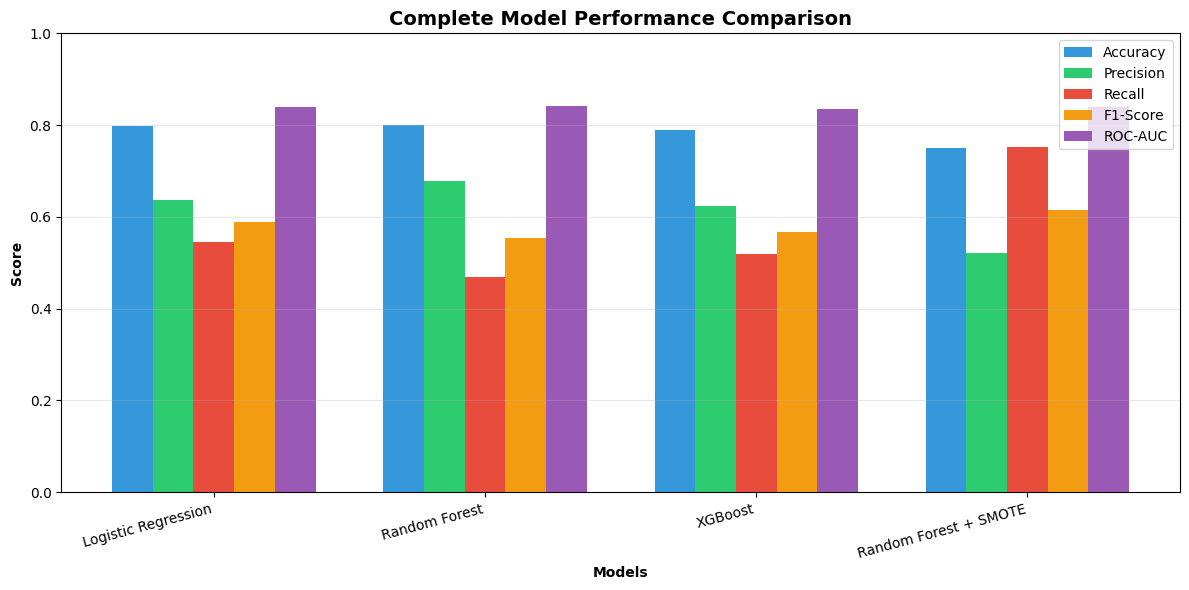


Model training and comparison complete!


In [48]:
# Final Model Comparison

print("FINAL MODEL COMPARISON")
print("="*60)

# Create comprehensive comparison
final_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'XGBoost',
        'Random Forest + SMOTE'
    ],
    'Accuracy': [accuracy, accuracy_rf, accuracy_xgb, accuracy_rf_smote],
    'Precision': [precision, precision_rf, precision_xgb, precision_rf_smote],
    'Recall': [recall, recall_rf, recall_xgb, recall_rf_smote],
    'F1-Score': [f1, f1_rf, f1_xgb, f1_rf_smote],
    'ROC-AUC': [roc_auc, roc_auc_rf, roc_auc_xgb, roc_auc_rf_smote]
})

print("\n", final_comparison.to_string(index=False))

# Find best model for each metric
print("\nBest Model for Each Metric:")
print(f"Best Accuracy:  {final_comparison.loc[final_comparison['Accuracy'].idxmax(), 'Model']} ({final_comparison['Accuracy'].max():.4f})")
print(f"Best Precision: {final_comparison.loc[final_comparison['Precision'].idxmax(), 'Model']} ({final_comparison['Precision'].max():.4f})")
print(f"Best Recall:    {final_comparison.loc[final_comparison['Recall'].idxmax(), 'Model']} ({final_comparison['Recall'].max():.4f})")
print(f"Best F1-Score:  {final_comparison.loc[final_comparison['F1-Score'].idxmax(), 'Model']} ({final_comparison['F1-Score'].max():.4f})")
print(f"Best ROC-AUC:   {final_comparison.loc[final_comparison['ROC-AUC'].idxmax(), 'Model']} ({final_comparison['ROC-AUC'].max():.4f})")

# Visualize final comparison
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(final_comparison))
width = 0.15

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']

for i, metric in enumerate(metrics):
    ax.bar(x + i*width, final_comparison[metric], width, 
           label=metric, color=colors[i])

ax.set_xlabel('Models', fontweight='bold')
ax.set_ylabel('Score', fontweight='bold')
ax.set_title('Complete Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 2)
ax.set_xticklabels(final_comparison['Model'], rotation=15, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0, 1])

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("Model training and comparison complete!")

In [49]:
# Train All Models with SMOTE

print("TRAINING ALL MODELS WITH SMOTE")
print("="*60)

# We already have X_train_smote and y_train_smote from Cell 16

# 1. Logistic Regression + SMOTE
print("\nTraining Logistic Regression + SMOTE...")
log_reg_smote = LogisticRegression(random_state=42, max_iter=1000)
log_reg_smote.fit(X_train_smote, y_train_smote)

y_pred_log_smote = log_reg_smote.predict(X_test)
y_pred_proba_log_smote = log_reg_smote.predict_proba(X_test)[:, 1]

accuracy_log_smote = accuracy_score(y_test, y_pred_log_smote)
precision_log_smote = precision_score(y_test, y_pred_log_smote)
recall_log_smote = recall_score(y_test, y_pred_log_smote)
f1_log_smote = f1_score(y_test, y_pred_log_smote)
roc_auc_log_smote = roc_auc_score(y_test, y_pred_proba_log_smote)

print(f"   Accuracy: {accuracy_log_smote:.4f}, Recall: {recall_log_smote:.4f}, F1: {f1_log_smote:.4f}")

# 2. XGBoost + SMOTE
print("\nTraining XGBoost + SMOTE...")
import xgboost as xgb
xgb_smote = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)
xgb_smote.fit(X_train_smote, y_train_smote)

y_pred_xgb_smote = xgb_smote.predict(X_test)
y_pred_proba_xgb_smote = xgb_smote.predict_proba(X_test)[:, 1]

accuracy_xgb_smote = accuracy_score(y_test, y_pred_xgb_smote)
precision_xgb_smote = precision_score(y_test, y_pred_xgb_smote)
recall_xgb_smote = recall_score(y_test, y_pred_xgb_smote)
f1_xgb_smote = f1_score(y_test, y_pred_xgb_smote)
roc_auc_xgb_smote = roc_auc_score(y_test, y_pred_proba_xgb_smote)

print(f"   Accuracy: {accuracy_xgb_smote:.4f}, Recall: {recall_xgb_smote:.4f}, F1: {f1_xgb_smote:.4f}")

# 3. Random Forest + SMOTE 
print("\nRandom Forest + SMOTE (already trained)")
print(f"   Accuracy: {accuracy_rf_smote:.4f}, Recall: {recall_rf_smote:.4f}, F1: {f1_rf_smote:.4f}")

print("\nAll models trained with SMOTE!")

TRAINING ALL MODELS WITH SMOTE

Training Logistic Regression + SMOTE...
   Accuracy: 0.7367, Recall: 0.6925, F1: 0.5827

Training XGBoost + SMOTE...
   Accuracy: 0.7544, Recall: 0.7219, F1: 0.6095

Random Forest + SMOTE (already trained)
   Accuracy: 0.7502, Recall: 0.7513, F1: 0.6149

All models trained with SMOTE!


ALL MODEL COMPARISON

Complete Model Comparison:

                      Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
        Logistic Regression  0.797019   0.637500 0.545455  0.587896 0.839242
Logistic Regression + SMOTE  0.736693   0.502913 0.692513  0.582677 0.819435
              Random Forest  0.799858   0.678295 0.467914  0.553797 0.842658
      Random Forest + SMOTE  0.750177   0.520370 0.751337  0.614880 0.839305
                    XGBoost  0.789212   0.623794 0.518717  0.566423 0.836156
            XGBoost + SMOTE  0.754436   0.527344 0.721925  0.609481 0.825823

SMOTE Impact Analysis:

Logistic Regression:
   Recall: 0.5455 → 0.6925 (Change: +14.71%)
   F1-Score: 0.5879 → 0.5827 (Change: -0.52%)

Random Forest:
   Recall: 0.4679 → 0.7513 (Change: +28.34%)
   F1-Score: 0.5538 → 0.6149 (Change: +6.11%)

XGBoost:
   Recall: 0.5187 → 0.7219 (Change: +20.32%)
   F1-Score: 0.5664 → 0.6095 (Change: +4.31%)

OVERALL BEST MODEL: Random Forest + SMOTE
   F1-Score: 0.6149
   

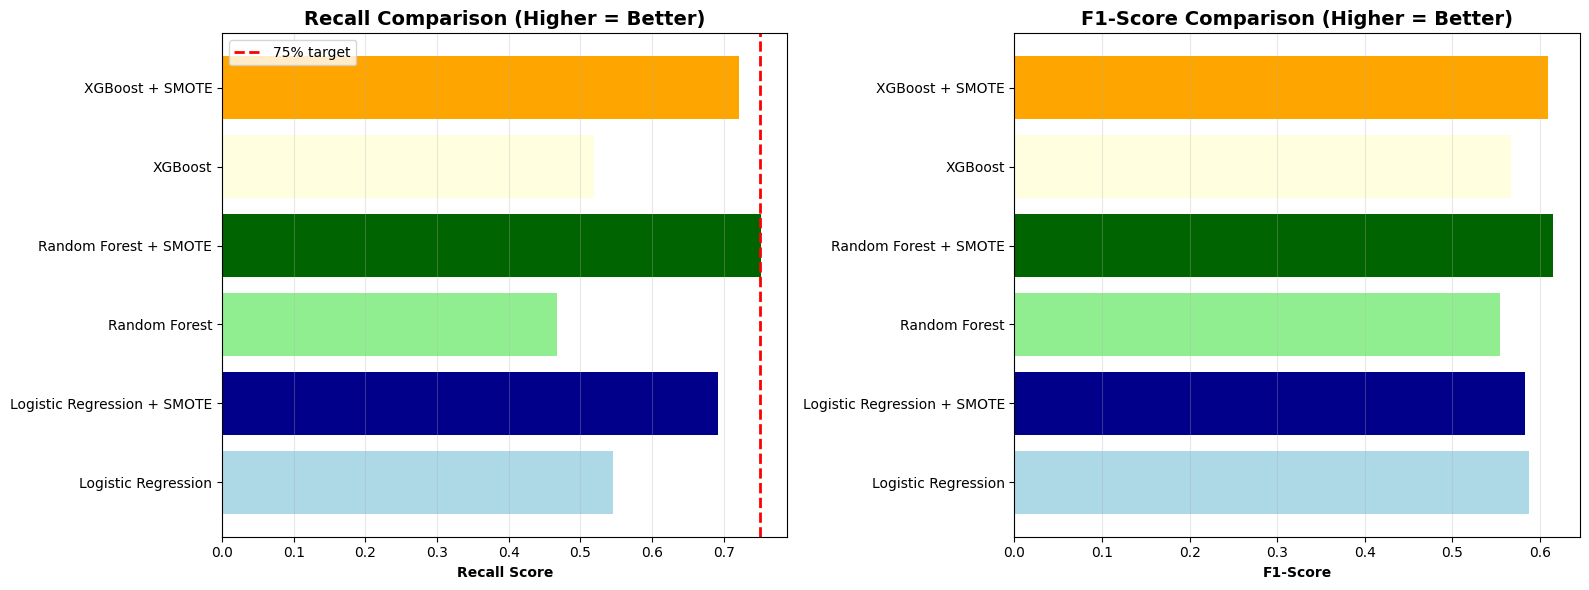


Complete model analysis finished!


In [50]:
# Ultimate Model Comparison - Original vs SMOTE

print("ALL MODEL COMPARISON")
print("="*60)

# Create comprehensive comparison
ultimate_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Logistic Regression + SMOTE',
        'Random Forest',
        'Random Forest + SMOTE',
        'XGBoost',
        'XGBoost + SMOTE'
    ],
    'Accuracy': [
        accuracy, accuracy_log_smote,
        accuracy_rf, accuracy_rf_smote,
        accuracy_xgb, accuracy_xgb_smote
    ],
    'Precision': [
        precision, precision_log_smote,
        precision_rf, precision_rf_smote,
        precision_xgb, precision_xgb_smote
    ],
    'Recall': [
        recall, recall_log_smote,
        recall_rf, recall_rf_smote,
        recall_xgb, recall_xgb_smote
    ],
    'F1-Score': [
        f1, f1_log_smote,
        f1_rf, f1_rf_smote,
        f1_xgb, f1_xgb_smote
    ],
    'ROC-AUC': [
        roc_auc, roc_auc_log_smote,
        roc_auc_rf, roc_auc_rf_smote,
        roc_auc_xgb, roc_auc_xgb_smote
    ]
})

print("\nComplete Model Comparison:\n")
print(ultimate_comparison.to_string(index=False))

# Highlight improvements from SMOTE
print("\nSMOTE Impact Analysis:")
print("="*60)

print("\nLogistic Regression:")
print(f"   Recall: {recall:.4f} → {recall_log_smote:.4f} (Change: {(recall_log_smote - recall)*100:+.2f}%)")
print(f"   F1-Score: {f1:.4f} → {f1_log_smote:.4f} (Change: {(f1_log_smote - f1)*100:+.2f}%)")

print("\nRandom Forest:")
print(f"   Recall: {recall_rf:.4f} → {recall_rf_smote:.4f} (Change: {(recall_rf_smote - recall_rf)*100:+.2f}%)")
print(f"   F1-Score: {f1_rf:.4f} → {f1_rf_smote:.4f} (Change: {(f1_rf_smote - f1_rf)*100:+.2f}%)")

print("\nXGBoost:")
print(f"   Recall: {recall_xgb:.4f} → {recall_xgb_smote:.4f} (Change: {(recall_xgb_smote - recall_xgb)*100:+.2f}%)")
print(f"   F1-Score: {f1_xgb:.4f} → {f1_xgb_smote:.4f} (Change: {(f1_xgb_smote - f1_xgb)*100:+.2f}%)")

# Find overall best model
best_f1_idx = ultimate_comparison['F1-Score'].idxmax()
best_model = ultimate_comparison.loc[best_f1_idx, 'Model']
best_f1 = ultimate_comparison.loc[best_f1_idx, 'F1-Score']

print("\n" + "="*60)
print(f"OVERALL BEST MODEL: {best_model}")
print(f"   F1-Score: {best_f1:.4f}")
print(f"   Recall: {ultimate_comparison.loc[best_f1_idx, 'Recall']:.4f}")
print(f"   Precision: {ultimate_comparison.loc[best_f1_idx, 'Precision']:.4f}")

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Recall comparison (most important metric)
models = ultimate_comparison['Model']
recall_scores = ultimate_comparison['Recall']
colors = ['lightblue', 'darkblue', 'lightgreen', 'darkgreen', 'lightyellow', 'orange']

axes[0].barh(range(len(models)), recall_scores, color=colors)
axes[0].set_yticks(range(len(models)))
axes[0].set_yticklabels(models)
axes[0].set_xlabel('Recall Score', fontweight='bold')
axes[0].set_title('Recall Comparison (Higher = Better)', fontsize=14, fontweight='bold')
axes[0].axvline(x=0.75, color='red', linestyle='--', linewidth=2, label='75% target')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='x')

# Plot 2: F1-Score comparison
f1_scores = ultimate_comparison['F1-Score']

axes[1].barh(range(len(models)), f1_scores, color=colors)
axes[1].set_yticks(range(len(models)))
axes[1].set_yticklabels(models)
axes[1].set_xlabel('F1-Score', fontweight='bold')
axes[1].set_title('F1-Score Comparison (Higher = Better)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("Complete model analysis finished!")
 
 

In [51]:
# Save Model and Preprocessing Objects

import joblib
import pickle
from datetime import datetime

print("SAVING MODEL AND ARTIFACTS")
print("="*60)

# Create models directory if it doesn't exist
import os
os.makedirs('../models', exist_ok=True)

# 1. Save the best model (Random Forest + SMOTE)
model_filename = '../models/best_model_rf_smote.pkl'
joblib.dump(rf_smote, model_filename)
print(f"Best model saved: {model_filename}")

# 2. Save the scaler (important for prediction!)
scaler_filename = '../models/scaler.pkl'
joblib.dump(scaler, scaler_filename)
print(f"Scaler saved: {scaler_filename}")

# 3. Save feature names (needed for prediction)
feature_names = X_train.columns.tolist()
features_filename = '../models/feature_names.pkl'
with open(features_filename, 'wb') as f:
    pickle.dump(feature_names, f)
print(f"Feature names saved: {features_filename}")

# 4. Save model metadata
metadata = {
    'model_name': 'Random Forest + SMOTE',
    'model_type': 'RandomForestClassifier',
    'training_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'n_features': len(feature_names),
    'n_samples_train': len(X_train_smote),
    'metrics': {
        'accuracy': float(accuracy_rf_smote),
        'precision': float(precision_rf_smote),
        'recall': float(recall_rf_smote),
        'f1_score': float(f1_rf_smote),
        'roc_auc': float(roc_auc_rf_smote)
    },
    'hyperparameters': {
        'n_estimators': 100,
        'max_depth': 10,
        'min_samples_split': 50,
        'random_state': 42
    },
    'smote_applied': True,
    'class_distribution_after_smote': {
        'class_0': int((y_train_smote == 0).sum()),
        'class_1': int((y_train_smote == 1).sum())
    }
}

metadata_filename = '../models/model_metadata.pkl'
with open(metadata_filename, 'wb') as f:
    pickle.dump(metadata, f)
print(f"Model metadata saved: {metadata_filename}")

# 5. Save column transformer info (for encoding)
encoding_info = {
    'binary_columns': ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling'],
    'gender_encoding': {'Male': 1, 'Female': 0},
    'categorical_columns': ['MultipleLines', 'InternetService', 'OnlineSecurity', 
                           'OnlineBackup', 'DeviceProtection', 'TechSupport',
                           'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod'],
    'numerical_columns': ['tenure', 'MonthlyCharges'],
    'target_encoding': {'No': 0, 'Yes': 1}
}

encoding_filename = '../models/encoding_info.pkl'
with open(encoding_filename, 'wb') as f:
    pickle.dump(encoding_info, f)
print(f"Encoding info saved: {encoding_filename}")

print("\n" + "="*60)
print("All model artifacts saved successfully!")
print("\nSaved files:")
print(f"  1. {model_filename}")
print(f"  2. {scaler_filename}")
print(f"  3. {features_filename}")
print(f"  4. {metadata_filename}")
print(f"  5. {encoding_filename}")

SAVING MODEL AND ARTIFACTS
Best model saved: ../models/best_model_rf_smote.pkl
Scaler saved: ../models/scaler.pkl
Feature names saved: ../models/feature_names.pkl
Model metadata saved: ../models/model_metadata.pkl
Encoding info saved: ../models/encoding_info.pkl

All model artifacts saved successfully!

Saved files:
  1. ../models/best_model_rf_smote.pkl
  2. ../models/scaler.pkl
  3. ../models/feature_names.pkl
  4. ../models/model_metadata.pkl
  5. ../models/encoding_info.pkl


In [52]:
# Test Model Loading and Prediction

print("TESTING MODEL LOADING AND PREDICTION")
print("="*60)

# Load all artifacts
print("\nLoading saved artifacts...")
loaded_model = joblib.load('../models/best_model_rf_smote.pkl')
loaded_scaler = joblib.load('../models/scaler.pkl')
with open('../models/feature_names.pkl', 'rb') as f:
    loaded_features = pickle.load(f)
with open('../models/model_metadata.pkl', 'rb') as f:
    loaded_metadata = pickle.load(f)

print("All artifacts loaded successfully!")

# Display metadata
print("\nModel Metadata:")
print(f"   Model: {loaded_metadata['model_name']}")
print(f"   Training Date: {loaded_metadata['training_date']}")
print(f"   F1-Score: {loaded_metadata['metrics']['f1_score']:.4f}")
print(f"   Recall: {loaded_metadata['metrics']['recall']:.4f}")

# Test prediction on a few samples from test set
print("\nTesting predictions on sample customers...")
print("="*60)

# Select 5 random samples
sample_indices = [0, 50, 100, 150, 200]
X_sample = X_test.iloc[sample_indices]
y_sample = y_test.iloc[sample_indices]

# Make predictions
predictions = loaded_model.predict(X_sample)
probabilities = loaded_model.predict_proba(X_sample)[:, 1]

# Display results
results_df = pd.DataFrame({
    'Actual_Churn': y_sample.values,
    'Predicted_Churn': predictions,
    'Churn_Probability': probabilities,
    'Risk_Level': ['High' if p > 0.7 else 'Medium' if p > 0.4 else 'Low' for p in probabilities]
})

print("\nSample Predictions:")
print(results_df.to_string(index=False))

# Verify predictions match
test_pred = loaded_model.predict(X_test)
test_accuracy = accuracy_score(y_test, test_pred)

print(f"\nVerification:")
print(f"   Test Accuracy: {test_accuracy:.4f}")
print(f"   Expected Accuracy: {accuracy_rf_smote:.4f}")
print(f"   Match: {'YES' if abs(test_accuracy - accuracy_rf_smote) < 0.0001 else '❌ NO'}")

print("\n" + "="*60)
print("Model loading and prediction test successful!")

TESTING MODEL LOADING AND PREDICTION

Loading saved artifacts...
All artifacts loaded successfully!

Model Metadata:
   Model: Random Forest + SMOTE
   Training Date: 2026-02-09 13:01:12
   F1-Score: 0.6149
   Recall: 0.7513

Testing predictions on sample customers...

Sample Predictions:
 Actual_Churn  Predicted_Churn  Churn_Probability Risk_Level
            0                0           0.045442        Low
            0                0           0.054798        Low
            1                1           0.841538       High
            0                0           0.110377        Low
            0                0           0.349931        Low

Verification:
   Test Accuracy: 0.7502
   Expected Accuracy: 0.7502
   Match: YES

Model loading and prediction test successful!


In [53]:
# Create Reusable Prediction Function

def predict_churn(customer_data, model_path='../models/best_model_rf_smote.pkl'):
    """
    Predict churn for new customer data
    
    Parameters:
    -----------
    customer_data : dict or pd.DataFrame
        Customer features in original format (before encoding)
    model_path : str
        Path to saved model
    
    Returns:
    --------
    dict : Prediction results with probability and risk level
    """
    import joblib
    import pickle
    import pandas as pd
    import numpy as np
    
    # Load artifacts
    model = joblib.load(model_path)
    scaler = joblib.load('../models/scaler.pkl')
    with open('../models/feature_names.pkl', 'rb') as f:
        feature_names = pickle.load(f)
    with open('../models/encoding_info.pkl', 'rb') as f:
        encoding_info = pickle.load(f)
    
    # Convert to DataFrame if dict
    if isinstance(customer_data, dict):
        df = pd.DataFrame([customer_data])
    else:
        df = customer_data.copy()
    
    # Feature engineering pipeline
    # 1. Binary encoding
    for col in encoding_info['binary_columns']:
        if col in df.columns:
            df[col] = df[col].map({'Yes': 1, 'No': 0})
    
    # 2. Gender encoding
    if 'gender' in df.columns:
        df['gender'] = df['gender'].map(encoding_info['gender_encoding'])
    
    # 3. One-hot encoding for categorical columns
    df_encoded = pd.get_dummies(df, columns=encoding_info['categorical_columns'], drop_first=True)
    
    # 4. Ensure all features exist (add missing with 0)
    for feature in feature_names:
        if feature not in df_encoded.columns:
            df_encoded[feature] = 0
    
    # 5. Reorder columns to match training
    df_encoded = df_encoded[feature_names]
    
    # 6. Scale numerical features
    cols_to_scale = encoding_info['numerical_columns']
    df_encoded[cols_to_scale] = scaler.transform(df_encoded[cols_to_scale])
    
    # Make prediction
    prediction = model.predict(df_encoded)[0]
    probability = model.predict_proba(df_encoded)[0, 1]
    
    # Determine risk level
    if probability > 0.7:
        risk_level = 'High'
        recommendation = 'Immediate retention action needed'
    elif probability > 0.4:
        risk_level = 'Medium'
        recommendation = 'Monitor closely and engage proactively'
    else:
        risk_level = 'Low'
        recommendation = 'Standard customer service'
    
    return {
        'will_churn': bool(prediction),
        'churn_probability': float(probability),
        'risk_level': risk_level,
        'recommendation': recommendation
    }

print("Prediction function created!")

# Test the function
print("\nTesting prediction function...")
print("="*60)

# Create a sample customer (high-risk profile)
sample_customer = {
    'gender': 'Female',
    'SeniorCitizen': 0,
    'Partner': 'No',
    'Dependents': 'No',
    'tenure': 3,
    'PhoneService': 'Yes',
    'MultipleLines': 'No',
    'InternetService': 'Fiber optic',
    'OnlineSecurity': 'No',
    'OnlineBackup': 'No',
    'DeviceProtection': 'No',
    'TechSupport': 'No',
    'StreamingTV': 'Yes',
    'StreamingMovies': 'Yes',
    'Contract': 'Month-to-month',
    'PaperlessBilling': 'Yes',
    'PaymentMethod': 'Electronic check',
    'MonthlyCharges': 95.50
}

print("\nSample Customer Profile:")
print("   Tenure: 3 months (NEW customer)")
print("   Contract: Month-to-month")
print("   Internet: Fiber optic")
print("   Payment: Electronic check")
print("   Monthly Charges: $95.50")

result = predict_churn(sample_customer)

print("\nPrediction Results:")
print(f"   Will Churn: {'YES' if result['will_churn'] else 'NO'}")
print(f"   Churn Probability: {result['churn_probability']:.2%}")
print(f"   Risk Level: {result['risk_level']}")
print(f"   Recommendation: {result['recommendation']}")

print("\n" + "="*60)
print("Prediction function working correctly!")

Prediction function created!

Testing prediction function...

Sample Customer Profile:
   Tenure: 3 months (NEW customer)
   Contract: Month-to-month
   Internet: Fiber optic
   Payment: Electronic check
   Monthly Charges: $95.50

Prediction Results:
   Will Churn: YES
   Churn Probability: 56.61%
   Risk Level: Medium
   Recommendation: Monitor closely and engage proactively

Prediction function working correctly!


In [54]:
# Setup Python Path

import sys
import os

# Get the project root directory (go up from notebooks to project root)
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))

# Add to Python path
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(f"Added to Python path: {project_root}")
print(f"\nCurrent working directory: {os.getcwd()}")
print(f"\nPython will now search in:")
for path in sys.path[:3]:  # Show first 3 paths
    print(f"   - {path}")

Added to Python path: E:\My Projects For CV\telecom-churn-mlops

Current working directory: E:\My Projects For CV\telecom-churn-mlops\notebooks

Python will now search in:
   - E:\My Projects For CV\telecom-churn-mlops
   - C:\Users\nacha\AppData\Local\Programs\Python\Python313\python313.zip
   - C:\Users\nacha\AppData\Local\Programs\Python\Python313\DLLs


In [57]:
# Now this will work!
from src.models import predict_churn

# Test
sample = {
    'gender': 'Female',
    'SeniorCitizen': 0,
    'Partner': 'No',
    'Dependents': 'No',
    'tenure': 3,
    'PhoneService': 'Yes',
    'MultipleLines': 'No',
    'InternetService': 'Fiber optic',
    'OnlineSecurity': 'No',
    'OnlineBackup': 'No',
    'DeviceProtection': 'No',
    'TechSupport': 'No',
    'StreamingTV': 'Yes',
    'StreamingMovies': 'Yes',
    'Contract': 'Month-to-month',
    'PaperlessBilling': 'Yes',
    'PaymentMethod': 'Electronic check',
    'MonthlyCharges': 95.50
}

result = predict_churn(sample)
print(" Module working!")
print(f"Churn Probability: {result['churn_probability']:.2%}")
print(f"Risk Level: {result['risk_level']}")
 

 Module working!
Churn Probability: 56.61%
Risk Level: Medium
